In [932]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load the dataset
data = pd.read_csv("./data/train.csv")
test_data = pd.read_csv("./data/test.csv")
data.info()
data.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [933]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [934]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


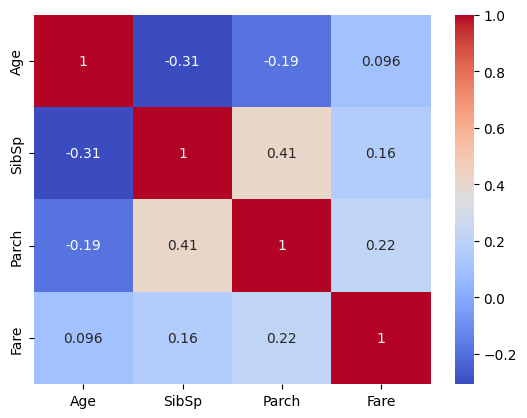

In [935]:
# explore data analysis
num_features = [ 'Age', 'SibSp', 'Parch', 'Fare']
cat_features = ['Pclass', 'Sex', 'Embarked']
p = data[num_features].corr()
sns.heatmap(p, annot=True, cmap="coolwarm")
plt.show()

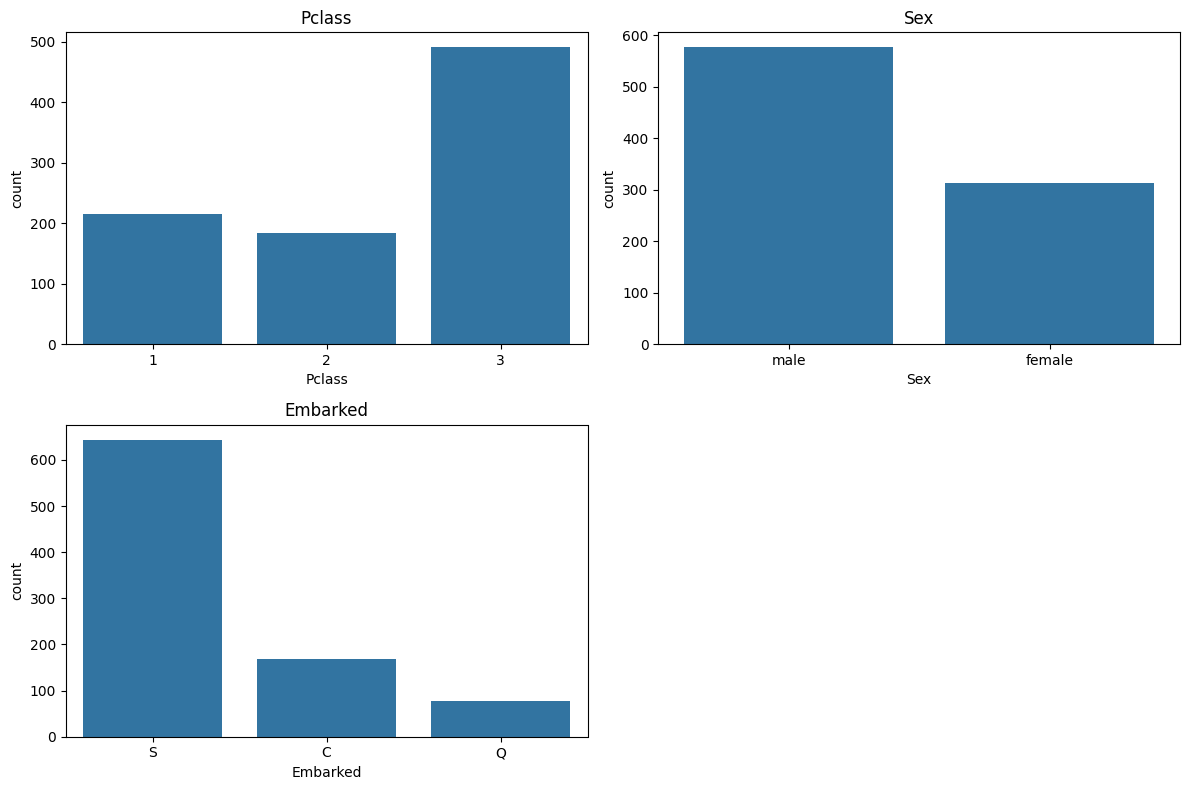

In [936]:
plt.figure(figsize=(12,8))

for i, col in enumerate(cat_features):
    plt.subplot(2,2,i+1)
    sns.countplot(data=data, x=col)
    plt.title(col)

plt.tight_layout()
plt.show()

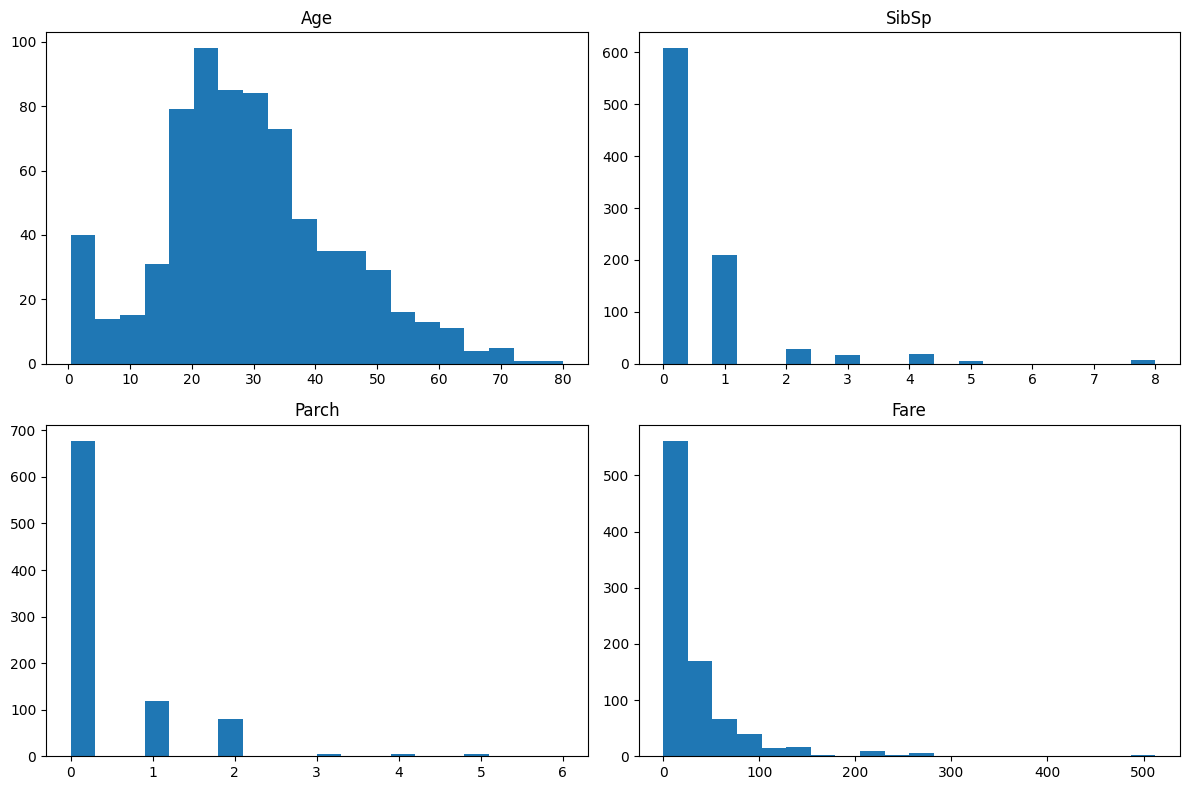

In [937]:
plt.figure(figsize=(12,8))
for i, feat in enumerate(num_features):
    plt.subplot(2,2, i+1)
    plt.hist(data[feat], bins=20)
    plt.title(feat)
plt.tight_layout()
plt.show()

In [938]:
# cleaning data and feature engineeringxs
X_train = data[num_features + cat_features].copy()
y_train = data["Survived"]
X_test = test_data[num_features + cat_features].copy()

# encode categorical columns as numbers
le_sex = LabelEncoder()
X_train["Sex"] = le_sex.fit_transform(X_train["Sex"])       # male=1, female=0
X_test["Sex"] = le_sex.fit_transform(X_test["Sex"])       # male=1, female=0

le_embarked = LabelEncoder()
X_train["Embarked"] = le_embarked.fit_transform(X_train["Embarked"])
X_test["Embarked"] = le_embarked.fit_transform(X_test["Embarked"])

# fill missing values
X_train["Age"] = X_train["Age"].fillna(X_train["Age"].median())
X_train["Embarked"] = X_train["Embarked"].fillna(X_train["Embarked"].mode()[0])

X_train.isna().sum()

Age         0
SibSp       0
Parch       0
Fare        0
Pclass      0
Sex         0
Embarked    0
dtype: int64

In [939]:
X_test.isna().sum

<bound method DataFrame.sum of        Age  SibSp  Parch   Fare  Pclass    Sex  Embarked
0    False  False  False  False   False  False     False
1    False  False  False  False   False  False     False
2    False  False  False  False   False  False     False
3    False  False  False  False   False  False     False
4    False  False  False  False   False  False     False
..     ...    ...    ...    ...     ...    ...       ...
413   True  False  False  False   False  False     False
414  False  False  False  False   False  False     False
415  False  False  False  False   False  False     False
416   True  False  False  False   False  False     False
417   True  False  False  False   False  False     False

[418 rows x 7 columns]>

In [940]:
X_test["Fare"] = X_test["Fare"].fillna(X_train["Fare"].median())
X_test["Age"] = X_test["Age"].fillna(X_train["Age"].median())
X_test.isna().sum()

Age         0
SibSp       0
Parch       0
Fare        0
Pclass      0
Sex         0
Embarked    0
dtype: int64

In [941]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train.isna().sum())
print(np.isinf(X_train.values).sum())
print(X_train_scaled.min(), X_train_scaled.max())

Age         0
SibSp       0
Parch       0
Fare        0
Pclass      0
Sex         0
Embarked    0
dtype: int64
0
-2.224156079948338 9.667166525013505


In [942]:
# Use cross-validation on the training set 
import warnings

from sklearn.model_selection import GridSearchCV
warnings.filterwarnings("ignore", category=RuntimeWarning)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "C": [0.001, 0.01, 0.05, 0.1, 0.5, 1, 10],
    "solver": ["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"]
}
base_model = LogisticRegression(max_iter=1000)

grid_search = GridSearchCV(base_model, param_grid, cv=cv, scoring="accuracy")
grid_search.fit(X_train_scaled, y_train)

results = pd.DataFrame(grid_search.cv_results_)[["param_C", "mean_test_score", "std_test_score"]]
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best mean CV accuracy: {grid_search.best_score_:.4f}")


Best parameters: {'C': 0.01, 'solver': 'lbfgs'}
Best mean CV accuracy: 0.8036


In [943]:
# using the best model found above 

model = grid_search.best_estimator_

y_pred = model.predict(X_test_scaled)

submission = pd.DataFrame({
    "PassengerId": test_data["PassengerId"],
    "Survived": y_pred
})

submission.to_csv("y_pred.csv", index=False)


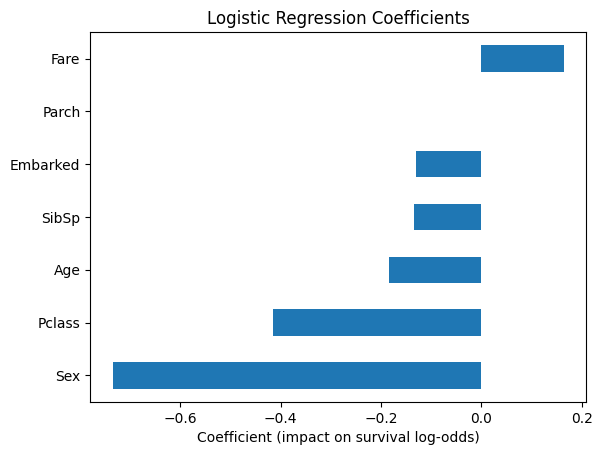

In [944]:
# which features are important
coef = pd.Series(model.coef_[0], index=X.columns).sort_values()
coef.plot(kind="barh", title="Logistic Regression Coefficients")
plt.xlabel("Coefficient (impact on survival log-odds)")
plt.show()